objective: Build and train a simply fully connected network on the MNIST dataset
what students will learn
how to load and preprocess MNIST dataset
How to build an MLP using sequential API in keras
The difference between train and validation accuracy.
How to plat traning curves and predictions.

Expectd outputs:
Training log showing and loss over epochs.
Accuracy curve plot and loss curve plot.
Test accuracy and loss printed in console.
Visualization of a few printed vs. actual labels.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
#1. Load and process MNIST dataset
(X_train, y_train),(X_test, y_test)= tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#Normalise pixel values to [0,1]
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [ ]:
#Flatten 28X28 images into vectors of size 784
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

In [ ]:
#2 . Define MLP model
model = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation= 'relu'),
    layers.Dense(64, activation= 'relu'),
    layers.Dense(10, activation= 'softmax')
])

In [ ]:
#3. Compile model
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#4. Train the model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=10, batch_size=64, verbose=1)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9126 - loss: 0.3077 - val_accuracy: 0.9509 - val_loss: 0.1683
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9624 - loss: 0.1258 - val_accuracy: 0.9666 - val_loss: 0.1154
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9730 - loss: 0.0906 - val_accuracy: 0.9656 - val_loss: 0.1151
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9802 - loss: 0.0651 - val_accuracy: 0.9714 - val_loss: 0.0949
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9839 - loss: 0.0518 - val_accuracy: 0.9684 - val_loss: 0.1037
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9870 - loss: 0.0418 - val_accuracy: 0.9746 - val_loss: 0.0924
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9899 - loss: 0.0322 - val_accuracy: 0.9719 - val_loss: 0.0992
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9910 - loss: 0.0283 - val_accuracy: 0.

In [ ]:
#5. Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"test Loss:{test_loss:.4f}")



Test Accuracy: 0.9740
test Loss:0.0987


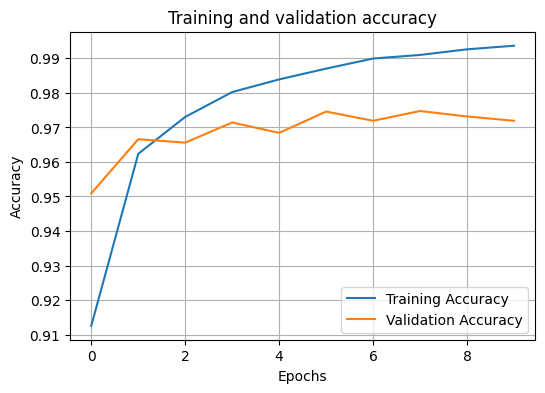

In [ ]:
#6. Plot accuracy curves
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title("Training and validation accuracy")
plt.legend()
plt.grid(True)
plt.show()


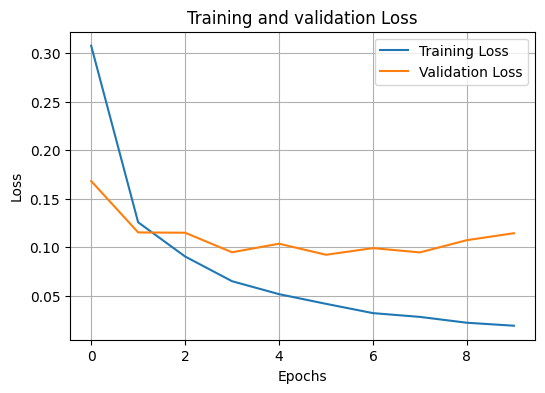

In [ ]:
#7. Plot loss curves
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title("Training and validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#8. Make predictions & display some results
import numpy as np

predictions = model.predict(X_test)
pred_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


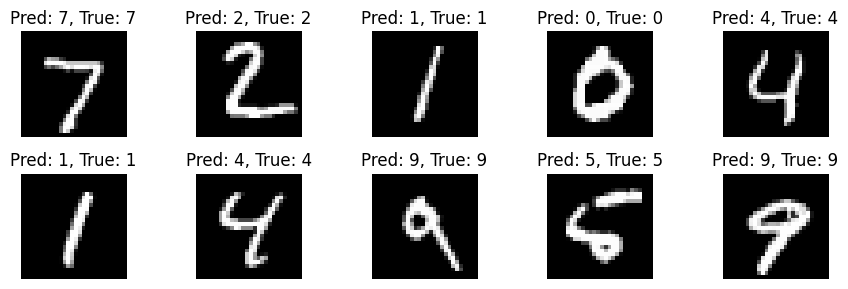

In [ ]:
#show first 10 images, preducted labels, and true labels
plt.figure(figsize=(10, 3))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
  plt.title(f"Pred: {pred_labels[i]}, True: {y_test[i]}")
  plt.axis('off')
  plt.tight_layout()